# Laboratorio 3 — Análisis exploratorio del alfabeto ASL

Este cuaderno cubre los **ejercicios 1 y 2** del laboratorio. El objetivo es entender el
conjunto de datos [ASL Alphabet](https://www.kaggle.com/datasets/grassknoted/aslalphabet)
antes de entrenar cualquier modelo: qué imágenes hay, en qué formato vienen, qué tan
balanceadas están las clases, cuánto varían las fotos de una misma letra, qué letras se
parecen entre sí y cómo se van a repartir los datos en entrenamiento, validación y prueba.

## Preguntas que guían la exploración

1. ¿Cuántas imágenes hay, de qué resolución y en qué formato?
2. ¿Está balanceado el conjunto de datos entre las 29 clases?
3. ¿Qué tanto varían las fotos **dentro** de una misma letra (iluminación, encuadre, mano)?
4. ¿Qué letras se parecen visualmente entre sí y podrían confundir al modelo?
5. ¿Cómo se debe construir el conjunto de entrenamiento, validación y prueba?

## 1. Preparación del entorno

Se importan las librerías y se fija la semilla aleatoria.

También se agrega la carpeta `src/` al path de Python para poder reutilizar las funciones de `download_dataset.py` en lugar de repetir código aquí.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Reproducibilidad: misma corrida -> mismos resultados
SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

# Hacemos visible la carpeta src/ para reutilizar el codigo de descarga
sys.path.append(str(Path.cwd().parent / "src"))
import download_dataset as dl

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_rows", 40)

print("Clases del dataset:", len(dl.CLASES))
print(dl.CLASES)

Clases del dataset: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


## 2. Obtención de los datos

La función `ensure_dataset()` descarga el dataset de Kaggle la primera vez y en las
siguientes corridas simplemente reutiliza lo que ya está en disco. Devuelve cuántas
imágenes tiene cada clase.

In [2]:
conteos = dl.ensure_dataset()

total = sum(conteos.values())
print(f"\nTotal de imagenes: {total:,}")
print(f"Clases: {len(conteos)}")
print("Primeras clases:", dict(list(conteos.items())[:5]))

Las 29 clases ya estan en /home/sebas/github/CC3084-Laboratorio-3/data/raw; se omite la descarga.



Total de imagenes: 87,000
Clases: 29
Primeras clases: {'A': 3000, 'B': 3000, 'C': 3000, 'D': 3000, 'E': 3000}


### 2.1 Inventario: ¿qué hay exactamente en disco?

Antes de mirar las imágenes conviene revisar sus **metadatos**: resolución, formato, modo de
color y peso en disco. La función `inventario()` recorre los archivos leyendo únicamente el
**encabezado** de cada JPG.

In [3]:
inv = dl.inventario()

print(f"Archivos inventariados: {len(inv):,}")
inv.head()

Archivos inventariados: 87,000


,clase,archivo,ancho,alto,modo,formato,bytes
0,A,A1.jpg,200,200,RGB,JPEG,11650
1,A,A10.jpg,200,200,RGB,JPEG,11584
2,A,A100.jpg,200,200,RGB,JPEG,11731
3,A,A1000.jpg,200,200,RGB,JPEG,12566
4,A,A1001.jpg,200,200,RGB,JPEG,13874


El inventario recorrió los **87,000 archivos** y devolvió, para cada uno, su clase, su tamaño en píxeles, su modo de color y su peso. Las primeras filas ya delatan el patrón: todas son de 200×200, en modo RGB y formato JPEG. Más adelante, se verifica sobre el total.

Un detalle que se nota en la columna `archivo`: los nombres están numerados (`A1.jpg`, `A10.jpg`, `A100.jpg`, …). Ese detalle resultará importante más adelante.

## 3. Ejercicio 1: Ejemplos del alfabeto y variabilidad dentro de una clase

Se muestran **seis letras distintas** y, de cada una, **seis fotografías diferentes**. Cada
fila es una letra; cada columna, una muestra distinta de esa misma letra.

Las letras elegidas no son al azar: **A, M, N y S** son puños cerrados que se distinguen solo
por dónde queda el pulgar, y **U y V** son dos dedos extendidos que se diferencian únicamente
por la separación entre ellos. Son justo los casos donde se espera que el modelo tenga
problemas.

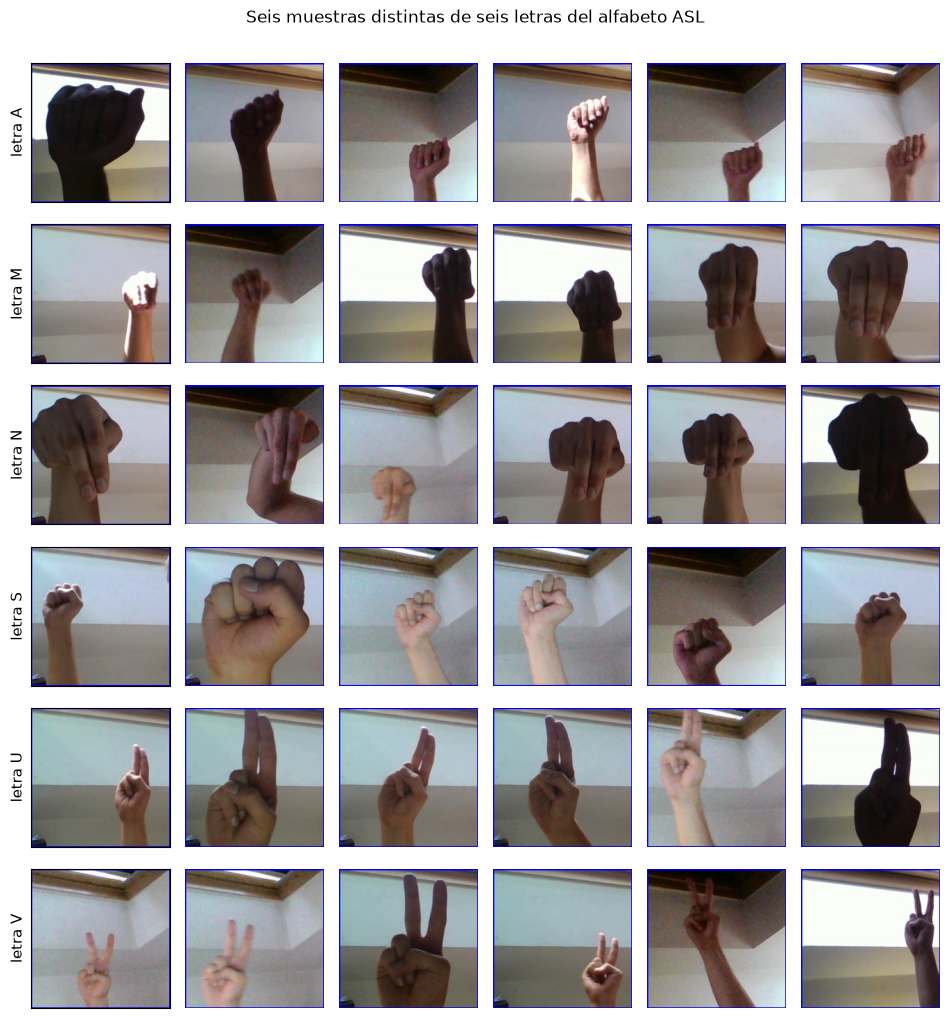

In [4]:
LETRAS_MUESTRA = ["A", "M", "N", "S", "U", "V"]
N_MUESTRAS = 6

rutas = dl.rutas_por_clase()

fig, axes = plt.subplots(len(LETRAS_MUESTRA), N_MUESTRAS,
                         figsize=(N_MUESTRAS * 1.6, len(LETRAS_MUESTRA) * 1.7))
for fila, letra in enumerate(LETRAS_MUESTRA):
    elegidas = rng.choice(len(rutas[letra]), N_MUESTRAS, replace=False)
    for col, idx in enumerate(elegidas):
        ax = axes[fila, col]
        ax.imshow(Image.open(rutas[letra][idx]))
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(letra)
    axes[fila, 0].axis("on")
    axes[fila, 0].set_xticks([]); axes[fila, 0].set_yticks([])
    axes[fila, 0].set_ylabel(f"letra {letra}", fontsize=11)

fig.suptitle("Seis muestras distintas de seis letras del alfabeto ASL", y=1.0)
plt.tight_layout()
plt.show()

Las seis muestras de cada letra confirman que la seña es siempre la misma, pero **la foto cambia muchísimo**. Tres fuentes de variación saltan a la vista:

- **Iluminación**: es la variación dominante. Dentro de una misma letra hay fotos donde la
  mano queda como una silueta casi negra (la primera muestra de la A, la tercera de la M) y
  otras sobreexpuestas donde apenas se distingue del fondo blanco.
- **Posición y tamaño de la mano**: la mano aparece a distintas alturas del encuadre y a
  distintas distancias de la cámara. En algunas fotos ocupa casi todo el cuadro y en otras es
  pequeña y está en una esquina.
- **Rotación de la muñeca**: la inclinación de la mano varía unos cuantos grados entre tomas.

En cambio, hay dos cosas que **no** varían: siempre es la **mano derecha** de la **misma
persona**, y el fondo es siempre la misma esquina de pared con una moldura de madera arriba.
Esa uniformidad hace la tarea más fácil de lo que sería en la vida real, y es una limitación
importante del dataset.

También se ve por qué las letras elegidas son difíciles: **A, M, N y S** son cuatro puños
cerrados que solo se diferencian en dónde queda el pulgar, y **U y V** son dos dedos
extendidos que se distinguen únicamente por si están juntos o separados.

### 3.1 ¿Qué tanto cambia una misma letra?

Para dimensionar la variabilidad dentro de una sola clase, se toman todas las muestras
disponibles de la letra **A**, se calcula el brillo medio de cada una y se muestran las
cuatro más oscuras junto a las cuatro más claras. Todas son la misma seña.

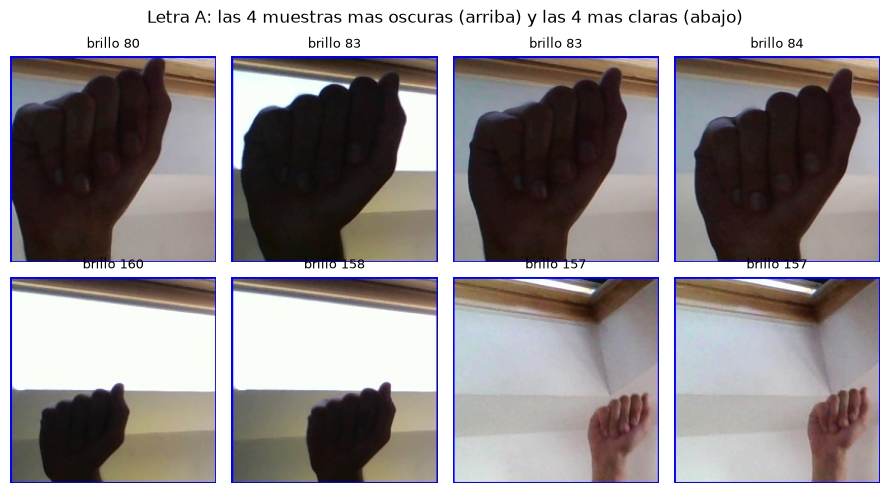

Brillo medio de la letra A: min=80.0, mediana=125.6, max=160.0


In [5]:
LETRA = "A"
muestra_idx = rng.choice(len(rutas[LETRA]), 300, replace=False)
archivos = [rutas[LETRA][i] for i in muestra_idx]

brillos = np.array([np.asarray(Image.open(p).convert("L")).mean() for p in archivos])
orden = np.argsort(brillos)

fig, axes = plt.subplots(2, 4, figsize=(9, 5))
for k in range(4):
    axes[0, k].imshow(Image.open(archivos[orden[k]]))
    axes[0, k].set_title(f"brillo {brillos[orden[k]]:.0f}", fontsize=9)
    axes[1, k].imshow(Image.open(archivos[orden[-(k + 1)]]))
    axes[1, k].set_title(f"brillo {brillos[orden[-(k + 1)]]:.0f}", fontsize=9)
for ax in axes.flat:
    ax.axis("off")
axes[0, 0].set_ylabel("mas oscuras")
fig.suptitle(f"Letra {LETRA}: las 4 muestras mas oscuras (arriba) y las 4 mas claras (abajo)")
plt.tight_layout()
plt.show()

print(f"Brillo medio de la letra {LETRA}: min={brillos.min():.1f}, "
      f"mediana={np.median(brillos):.1f}, max={brillos.max():.1f}")

Dentro de una sola letra, el brillo medio va de **80 a 160** sobre una escala de 0 a 255, con una mediana de 125.6. Es decir: **la misma seña puede ser el doble de brillante según la toma**. Las cuatro fotos de abajo se ven claramente como una mano; las cuatro de arriba son casi siluetas negras.

Esto tiene dos consecuencias para el modelo: tendrá que aprender a reconocer la forma pese a la iluminación, y el aumento de datos con variación de brillo será una transformación razonable porque reproduce algo que ya ocurre en los datos reales.

## 4. Ejercicio 2: Análisis exploratorio

### 4.1 Resolución y formato de las imágenes

Primera pregunta: ¿todas las imágenes tienen el mismo tamaño y formato? Si no lo tuvieran,
habría que homogeneizarlas antes de entrenar (como pasa en el clásico dataset de perros y
gatos, donde cada foto tiene una resolución distinta).

In [6]:
print("Resolucion (ancho x alto):")
print(inv.groupby(["ancho", "alto"]).size().rename("imagenes").to_string())

print("\nFormato de archivo:")
print(inv["formato"].value_counts().to_string())

print("\nModo de color:")
print(inv["modo"].value_counts().to_string())

print("\nPeso en disco (KB):")
print((inv["bytes"] / 1024).describe().round(2).to_string())

Resolucion (ancho x alto):
ancho  alto
200    200     87000

Formato de archivo:
formato
JPEG    87000

Modo de color:
modo
RGB    87000

Peso en disco (KB):
count    87000.00
mean        12.42
std          1.28
min          8.71
25%         11.32
50%         12.48
75%         13.53
max         15.75


El dataset es completamente **homogéneo** en formato:

- **Resolución**: las 87,000 imágenes son de **200×200 píxeles**, sin una sola excepción.
- **Formato**: todas son **JPEG**.
- **Modo de color**: todas son **RGB** (tres canales), ninguna en escala de grises.
- **Peso**: entre 8.71 y 15.75 KB, con una media de 12.42 KB.

Esto simplifica mucho el preprocesamiento. No hace falta homogeneizar las fotos antes de poder armar un tensor. La única razón para cambiar la resolución será **reducir el costo de cómputo**, no arreglar inconsistencias.

### 4.2 Distribución de clases: ¿está balanceado el dataset?

Un dataset **desbalanceado** empuja al modelo a favorecer las clases mayoritarias y obliga a usar métricas y técnicas especiales. Se revisa el conteo de imágenes por clase.

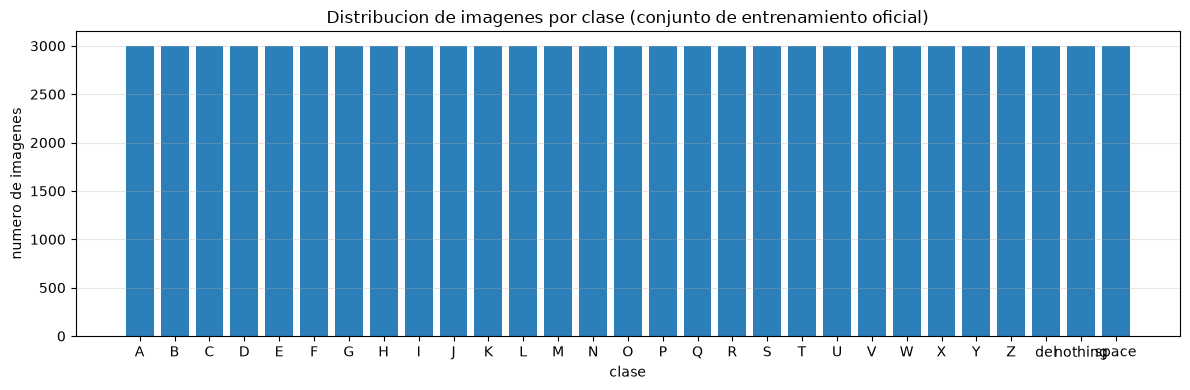

minimo: 3,000   maximo: 3,000   desviacion estandar: 0.00
Todas las clases tienen el mismo numero de imagenes: True


In [7]:
serie = pd.Series(conteos)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(serie.index, serie.values, color="#2c7fb8")
ax.set_xlabel("clase"); ax.set_ylabel("numero de imagenes")
ax.set_title("Distribucion de imagenes por clase (conjunto de entrenamiento oficial)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"minimo: {serie.min():,}   maximo: {serie.max():,}   "
      f"desviacion estandar: {serie.std():.2f}")
print(f"Todas las clases tienen el mismo numero de imagenes: {serie.nunique() == 1}")

El dataset está **perfectamente balanceado**: las 29 clases tienen exactamente **3,000 imágenes** cada una, con una desviación estándar de 0.00 entre clases.

Esto es bueno y simplifica varias decisiones:

- La **exactitud (accuracy)** es una métrica confiable; no hará falta corregirla por
  desbalance. La línea base de adivinar al azar es 1/29 ≈ **3.4 %**.
- No se necesitan pesos por clase ni técnicas de sobremuestreo.
- Cualquier submuestra que tome el mismo número de imágenes por clase **conserva el balance**.

### 4.3 Muestra de trabajo para las estadísticas de píxeles

Por motivos de recursos, para las siguientes secciones se carga una **muestra aleatoria de 150 imágenes por clase**, reescaladas a 64×64. Son 4,350 imágenes, suficientes para estimar promedios por clase de forma estable y lo bastante ligeras para trabajar cómodamente.

In [8]:
N_MUESTRA_CLASE = 150
TAM = 64

X_muestra = np.empty((len(dl.CLASES) * N_MUESTRA_CLASE, TAM, TAM, 3), dtype="uint8")
y_muestra = np.empty(len(X_muestra), dtype="int64")

pos = 0
for idx, clase in enumerate(dl.CLASES):
    elegidas = rng.choice(len(rutas[clase]), N_MUESTRA_CLASE, replace=False)
    for i in elegidas:
        with Image.open(rutas[clase][i]) as img:
            X_muestra[pos] = np.asarray(img.convert("RGB").resize((TAM, TAM),
                                                                  Image.BILINEAR))
        y_muestra[pos] = idx
        pos += 1

print(f"Muestra de trabajo: {X_muestra.shape}  ({X_muestra.nbytes / 1e6:.0f} MB en uint8)")

Muestra de trabajo: (4350, 64, 64, 3)  (53 MB en uint8)


### 4.4 Brillo y contraste por clase

Se cruzan dos variables: la **clase** y las estadísticas de intensidad de sus píxeles. El *brillo* es el valor promedio de gris de una imagen y el *contraste* es su desviación estándar.

Si alguna clase resultara sistemáticamente más oscura o con menos contraste que las demás, el modelo podría aprender a reconocerla por su iluminación y no por la forma de la mano.

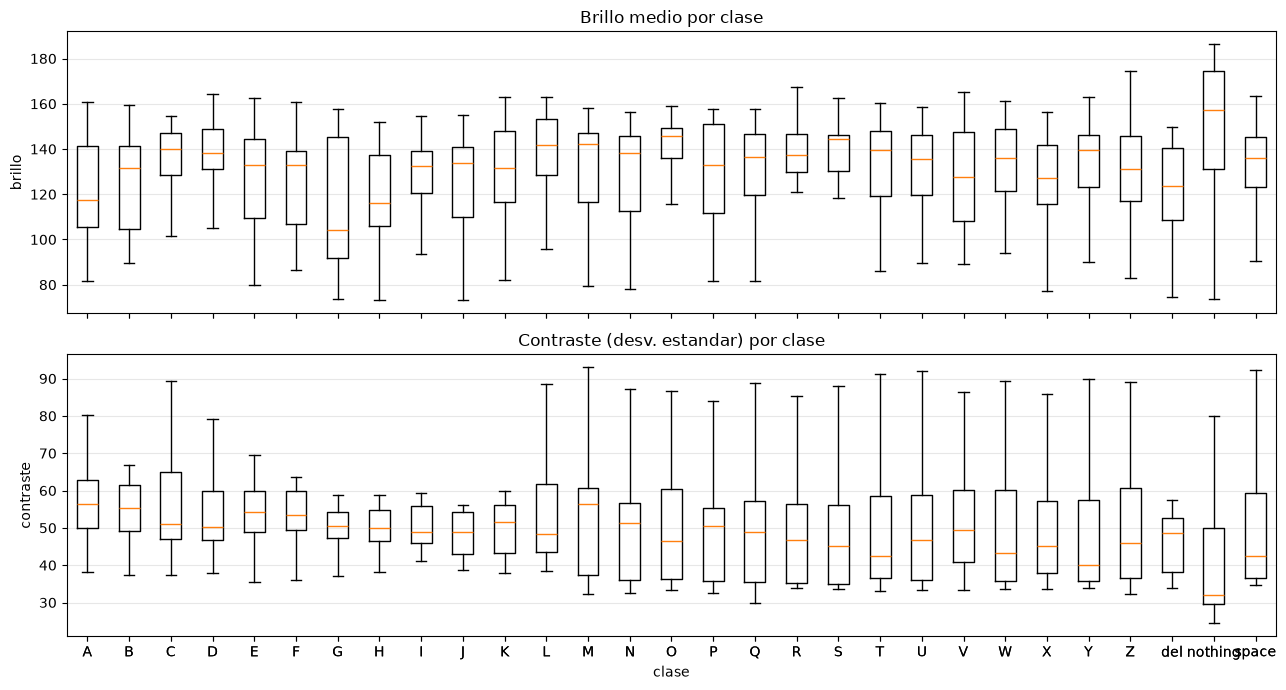

Clases mas oscuras:
        brillo  contraste
clase                   
G       116.1       53.3
H       119.3       54.2
del     120.6       51.4

Clases mas claras:
          brillo  contraste
clase                     
nothing   149.6       40.6
O         140.2       51.5
L         137.2       55.2

Rango del brillo medio entre clases: 116.1 a 149.6


In [9]:
gris = X_muestra @ np.array([0.299, 0.587, 0.114])   # RGB -> luminancia
brillo = gris.reshape(len(gris), -1).mean(axis=1)
contraste = gris.reshape(len(gris), -1).std(axis=1)

stats = pd.DataFrame({"clase": [dl.CLASES[i] for i in y_muestra],
                      "brillo": brillo, "contraste": contraste})

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, columna, titulo in zip(axes, ["brillo", "contraste"],
                               ["Brillo medio por clase", "Contraste (desv. estandar) por clase"]):
    datos = [stats.loc[stats["clase"] == c, columna].values for c in dl.CLASES]
    ax.boxplot(datos, tick_labels=dl.CLASES, showfliers=False)
    ax.set_title(titulo)
    ax.set_ylabel(columna)
    ax.grid(axis="y", alpha=0.3)
axes[1].set_xlabel("clase")
plt.tight_layout()
plt.show()

resumen = stats.groupby("clase")[["brillo", "contraste"]].mean().round(1)
print("Clases mas oscuras:\n", resumen.nsmallest(3, "brillo").to_string())
print("\nClases mas claras:\n", resumen.nlargest(3, "brillo").to_string())
print(f"\nRango del brillo medio entre clases: "
      f"{resumen['brillo'].min():.1f} a {resumen['brillo'].max():.1f}")

Comparando las **medianas** entre clases, la letra **G** es la más oscura (brillo medio 116.1) y la clase **nothing** la más clara (149.6). El rango completo entre clases es de 116 a 150.

Pero lo importante es la comparación entre las dos escalas de variación:

- **Entre clases** el brillo medio varía unos **34 puntos**.
- **Dentro de una misma clase** las cajas y bigotes se extienden de ~75 a ~175, es decir unos
  **100 puntos**.

La variación *dentro* de cada clase es unas tres veces mayor que la variación *entre* clases.
Eso significa que **el brillo no sirve como atajo para identificar la letra**: no hay ninguna
clase sistemáticamente oscura o clara que el modelo pueda reconocer solo por su iluminación.

El contraste cuenta la misma historia: las medianas van de ~40 (`nothing`) a ~57 (A, M), con
un solapamiento enorme entre clases. `nothing` tiene el contraste más bajo.

### 4.5 Color promedio por clase

Otro cruce útil: el valor medio de cada canal RGB por clase. Todas las fotos fueron tomadas
por la misma persona en el mismo entorno, así que se espera que el color sea muy parecido
entre clases. Si lo es, el color **no** sirve para distinguir letras y el modelo tendrá que
apoyarse en la forma.

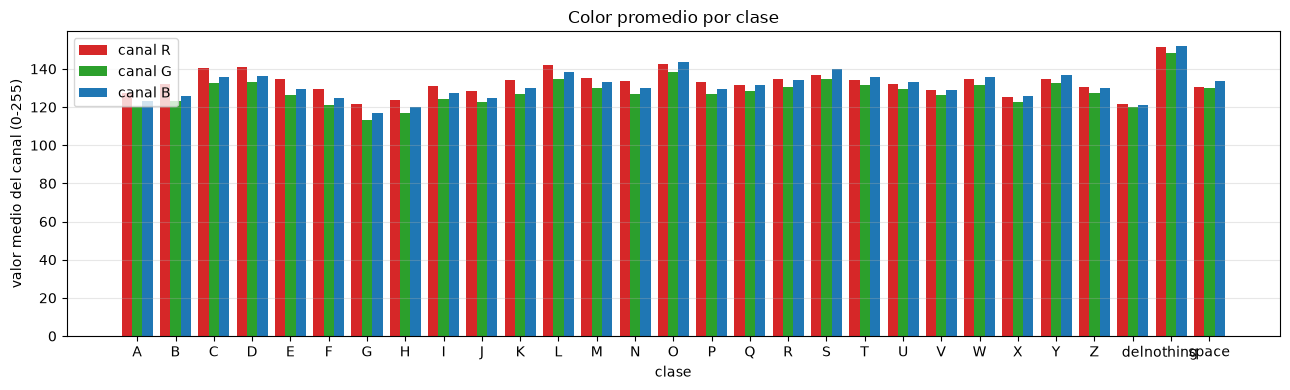

clase      A      B      C      D      E      F      G      H      I      J      K      L      M      N      O      P      Q      R      S      T      U      V      W      X      Y      Z    del  nothing  space
R      127.6  132.3  140.3  140.8  134.7  129.5  121.6  123.5  131.2  128.3  134.0  142.1  135.4  133.5  142.7  132.9  131.8  134.8  136.9  134.3  132.0  129.1  134.9  125.2  134.6  130.6  121.6    151.4  130.7
G      119.8  122.9  132.7  133.1  126.4  121.0  113.1  117.0  124.3  122.5  127.0  134.5  129.8  127.1  138.4  127.0  128.4  130.8  135.0  131.6  129.5  126.3  131.7  122.8  132.4  127.2  119.9    148.1  130.2
B      122.9  126.0  135.7  136.1  129.6  124.6  116.7  119.9  127.5  125.0  129.9  138.5  133.3  130.2  143.5  129.3  131.8  134.3  139.9  135.8  132.9  129.0  135.7  125.7  136.6  130.2  121.2    152.1  133.7

Variacion entre clases (desv. est. del promedio por canal): R=6.47, G=6.93, B=7.39


In [10]:
canales = pd.DataFrame({
    "clase": [dl.CLASES[i] for i in y_muestra],
    "R": X_muestra[..., 0].reshape(len(X_muestra), -1).mean(axis=1),
    "G": X_muestra[..., 1].reshape(len(X_muestra), -1).mean(axis=1),
    "B": X_muestra[..., 2].reshape(len(X_muestra), -1).mean(axis=1),
}).groupby("clase").mean().reindex(dl.CLASES)

fig, ax = plt.subplots(figsize=(13, 4))
x = np.arange(len(dl.CLASES))
for k, (canal, color) in enumerate(zip("RGB", ["#d62728", "#2ca02c", "#1f77b4"])):
    ax.bar(x + (k - 1) * 0.27, canales[canal], width=0.27, label=f"canal {canal}", color=color)
ax.set_xticks(x); ax.set_xticklabels(dl.CLASES)
ax.set_xlabel("clase"); ax.set_ylabel("valor medio del canal (0-255)")
ax.set_title("Color promedio por clase")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(canales.round(1).T.to_string())
print(f"\nVariacion entre clases (desv. est. del promedio por canal): "
      f"R={canales['R'].std():.2f}, G={canales['G'].std():.2f}, B={canales['B'].std():.2f}")

Los tres canales se mueven casi al unísono: el promedio por clase ronda 120–150 en los tres, con el rojo siempre un poco por encima del azul y el verde siempre abajo.

La desviación estándar del promedio **entre clases** es de apenas **6.5 (R), 6.9 (G) y 7.4 (B)** sobre valores medios de ~130, es decir alrededor de un **5 %** de variación. La única clase que se despega es `nothing` (R=151.4), y no porque tenga un color distinto sino porque no hay una mano oscureciendo el cuadro.

**Conclusión: el color no distingue las letras.** Todas las fotos son de la misma persona, en el mismo cuarto y con la misma luz, así que el tono de piel y el fondo son constantes. El modelo tendrá que apoyarse en la **forma**, que es lo deseable. Esto también justifica que, para el algoritmo clásico, se pueda trabajar en escala de grises sin perder casi nada.

### 4.6 La seña "promedio" de cada clase

Promediar píxel a píxel todas las imágenes de una clase borra los detalles particulares de
cada foto y deja a la vista **lo que tienen en común**: la silueta típica de la mano en esa
posición. Es una forma rápida de intuir qué patrón va a aprender la red.

Junto a la media se grafica la **desviación estándar** por píxel, que muestra *dónde* varían
más las imágenes de una misma clase.

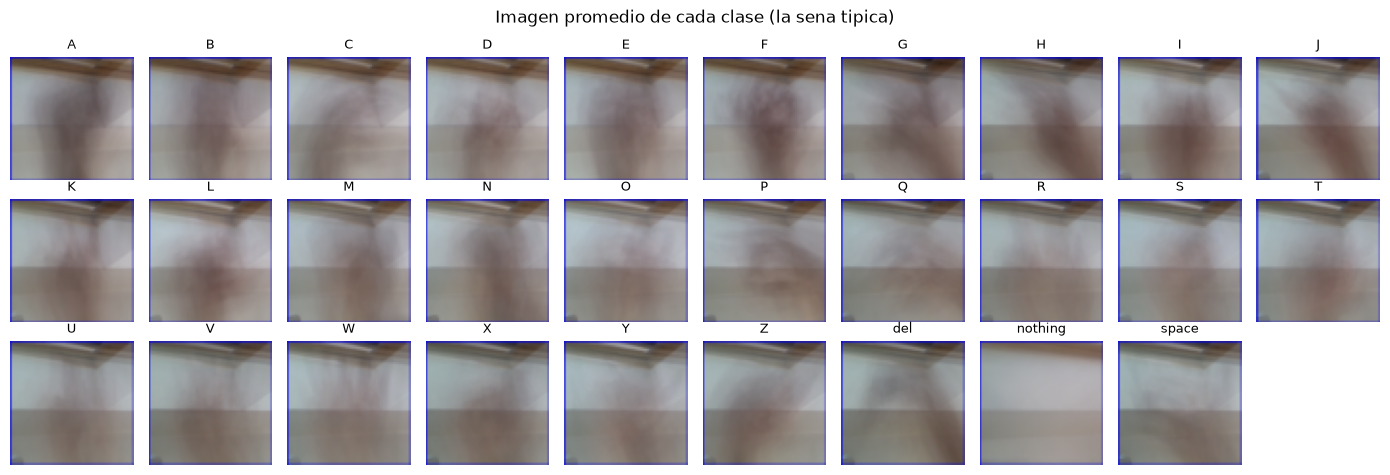

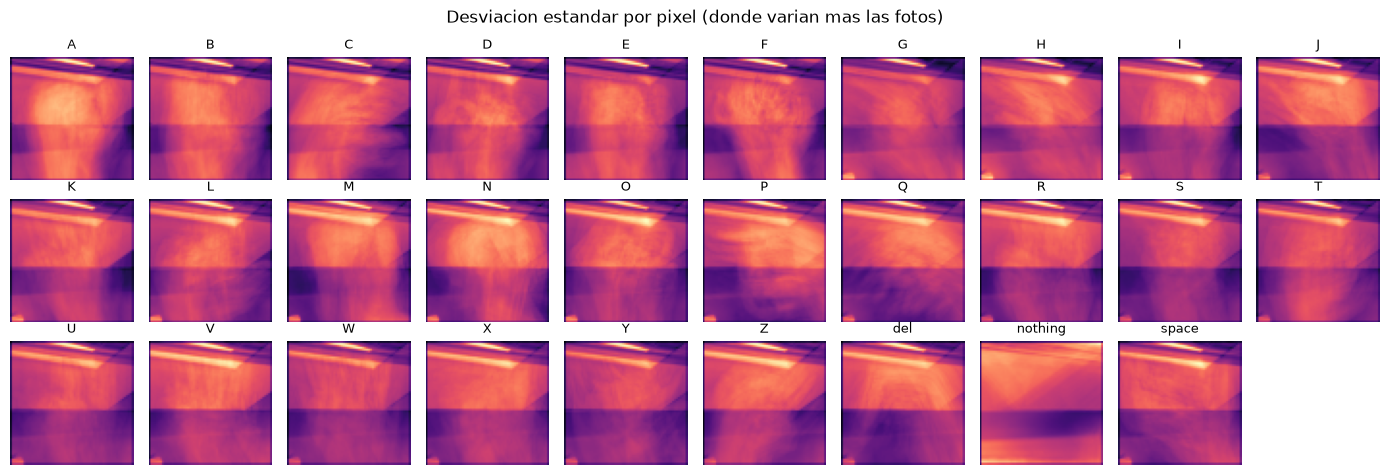

In [11]:
medias = np.stack([X_muestra[y_muestra == i].mean(axis=0) for i in range(len(dl.CLASES))])
desviaciones = np.stack([X_muestra[y_muestra == i].std(axis=0) for i in range(len(dl.CLASES))])

def mosaico(imagenes, titulo, cmap=None):
    fig, axes = plt.subplots(3, 10, figsize=(14, 4.8))
    for k, ax in enumerate(axes.flat):
        if k < len(imagenes):
            ax.imshow(imagenes[k].astype("uint8") if cmap is None else imagenes[k], cmap=cmap)
            ax.set_title(dl.CLASES[k], fontsize=9)
        ax.axis("off")
    fig.suptitle(titulo)
    plt.tight_layout()
    plt.show()

mosaico(medias, "Imagen promedio de cada clase (la sena tipica)")
mosaico(desviaciones.mean(axis=3), "Desviacion estandar por pixel (donde varian mas las fotos)",
        cmap="magma")

Estos dos mosaicos revelan algo que los promedios numéricos no mostraban.

En las **imágenes promedio**, lo que sobrevive con nitidez no es la mano sino **el fondo**: se ve clarísima la esquina de la pared, la moldura de madera arriba y la franja horizontal del mueble. La mano queda apenas como una **mancha borrosa** en el centro, porque su posición cambia demasiado entre fotos como para promediarse en una silueta definida. La clase `nothing` es la prueba: su promedio es simplemente el fondo limpio, sin ninguna mancha.

Las **desviaciones estándar** confirman el diagnóstico: las zonas de mayor variación (las más claras) no están concentradas donde va la mano, sino repartidas por toda la mitad superior de la imagen, con un trazo brillante justo sobre la moldura. Es decir, **la mayor parte de la variación de píxeles la produce la luz, no la mano**. La clase `nothing` (que no tiene mano alguna) es de las que más varía.

Esto matiza lo que el modelo tendrá que hacer: no le basta con localizar una forma sobre un fondo estable, porque el fondo también cambia con la iluminación.

### 4.7 ¿Qué letras se confunden visualmente entre sí?

Se convierten las 29 imágenes promedio a escala de grises, se aplanan a vectores de 4,096 valores y se calcula la **distancia euclidiana** entre cada par de clases. Mientras menor sea la distancia, más se parecen las señas promedio de esas dos letras y mayor es el riesgo de que el modelo las confunda.

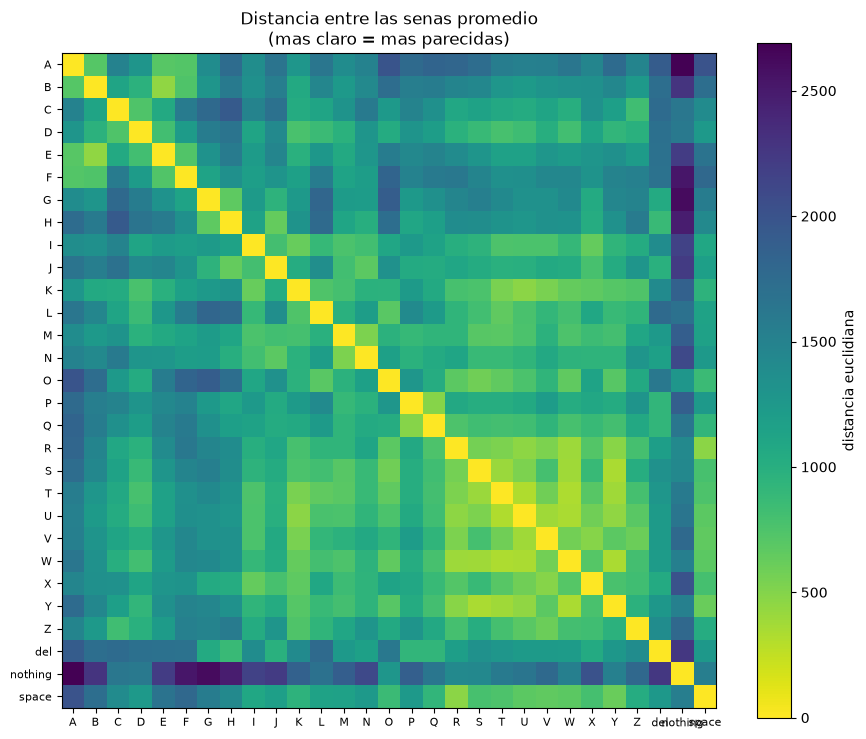

Los 12 pares de clases mas parecidos entre si:
letra A letra B  distancia
      T       U      318.5
      T       W      331.0
      U       W      338.4
      S       Y      339.6
      W       Y      342.1
      U       V      380.4
      T       Y      385.1
      S       W      388.8
      R       W      397.8
      S       T      404.6
      U       Y      443.3
      B       E      450.2


In [12]:
medias_gris = (medias @ np.array([0.299, 0.587, 0.114])).reshape(len(dl.CLASES), -1)

# Distancia euclidiana entre cada par de clases
dist = np.linalg.norm(medias_gris[:, None, :] - medias_gris[None, :, :], axis=2)

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(dist, cmap="viridis_r")
ax.set_xticks(range(len(dl.CLASES))); ax.set_xticklabels(dl.CLASES, fontsize=8)
ax.set_yticks(range(len(dl.CLASES))); ax.set_yticklabels(dl.CLASES, fontsize=8)
ax.set_title("Distancia entre las senas promedio\n(mas claro = mas parecidas)")
fig.colorbar(im, ax=ax, label="distancia euclidiana")
plt.tight_layout()
plt.show()

# Los 12 pares mas parecidos
pares = [(dl.CLASES[i], dl.CLASES[j], dist[i, j])
         for i in range(len(dl.CLASES)) for j in range(i + 1, len(dl.CLASES))]
top = pd.DataFrame(sorted(pares, key=lambda t: t[2])[:12],
                   columns=["letra A", "letra B", "distancia"])
print("Los 12 pares de clases mas parecidos entre si:")
print(top.round(1).to_string(index=False))

**Interpretación del mapa de calor**: hay un **bloque claro** (distancias pequeñas) en la esquina que agrupa a **R, S, T, U, V, W, X, Y**. Son las letras donde la mano se mantiene compacta y ocupa una porción parecida del encuadre. Al otro extremo, la fila y la columna de **`nothing`** son las más oscuras de todo el mapa: es la clase más distinta de todas.

La tabla confirma que los pares más cercanos salen casi todos de ese bloque: **T–U (318.5), T–W (331.0), U–W (338.4), S–Y (339.6), W–Y (342.1)**.

Para confirmar que la distancia captura algo real, se grafican lado a lado las señas promedio
de los tres pares más cercanos.

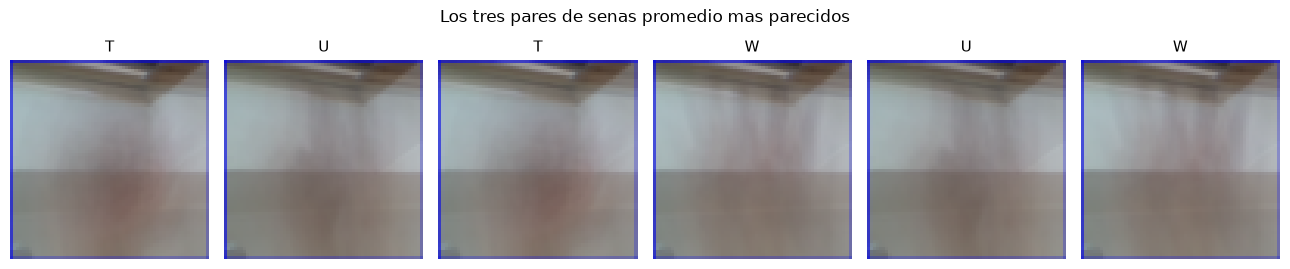

Distancia de los pares que anticipa el enunciado:
  M-N: distancia  530.6  (puesto 20 de 406 pares)
  M-S: distancia  702.2  (puesto 52 de 406 pares)
  N-S: distancia  877.1  (puesto 109 de 406 pares)
  U-V: distancia  380.4  (puesto 6 de 406 pares)
  U-R: distancia  461.8  (puesto 13 de 406 pares)
  V-R: distancia  531.4  (puesto 21 de 406 pares)


In [13]:
fig, axes = plt.subplots(1, 6, figsize=(13, 2.8))
for k in range(3):
    a, b = top.iloc[k]["letra A"], top.iloc[k]["letra B"]
    for offset, letra in enumerate([a, b]):
        ax = axes[k * 2 + offset]
        ax.imshow(medias[dl.CLASES.index(letra)].astype("uint8"))
        ax.set_title(f"{letra}", fontsize=11)
        ax.axis("off")
    axes[k * 2].set_xlabel(f"d={top.iloc[k]['distancia']:.0f}")
fig.suptitle("Los tres pares de senas promedio mas parecidos")
plt.tight_layout()
plt.show()

# Los pares que el enunciado del laboratorio anticipa como confusos
sospechosos = [("M", "N"), ("M", "S"), ("N", "S"), ("U", "V"), ("U", "R"), ("V", "R")]
print("Distancia de los pares que anticipa el enunciado:")
for a, b in sospechosos:
    d = dist[dl.CLASES.index(a), dl.CLASES.index(b)]
    rango = sorted(p[2] for p in pares).index(d) + 1
    print(f"  {a}-{b}: distancia {d:6.1f}  (puesto {rango} de {len(pares)} pares)")

**Interpretación y Advertencia sobre el Método**

Las imágenes promedio de T, U y W que se acaban de graficar son casi indistinguibles a simple
vista: en las tres se ve el mismo fondo con una mancha tenue de piel abajo. Esto revela
**qué está midiendo realmente la distancia**: no la configuración de los dedos, sino
**cuánto espacio ocupa la mano y dónde**. Como al promediar 150 fotos los dedos se difuminan,
lo que queda es la silueta gruesa.

Aun así, el resultado es informativo. Comparado con los pares que el enunciado del laboratorio
anticipa como confusos, la posición en el ranking de 406 pares posibles es:

| Par | Distancia | Puesto |
|---|---|---|
| U–V | 380.4 | 6 de 406 |
| U–R | 461.8 | 13 de 406 |
| M–N | 530.6 | 20 de 406 |
| V–R | 531.4 | 21 de 406 |
| M–S | 702.2 | 52 de 406 |
| N–S | 877.1 | 109 de 406 |

**Todos los pares que anticipa el enunciado caen en el cuartil más parecido**, lo cual valida
la sospecha. Pero los datos añaden matices propios:

- El grupo **U/V/R** aparece más arriba en el ranking (puestos 6, 13 y 21) que el grupo
  **M/N/S** (puestos 20, 52 y 109). Con esta medida, los dedos extendidos se confunden más
  entre sí que los puños cerrados.
- **N–S**, en el puesto 109, es el par menos preocupante de los seis.
- Aparecen candidatos que el laboratorio no mencionaba y que quedan en los primeros puestos:
  **T–U, T–W, U–W, S–Y y W–Y**.

La palabra final sobre qué se confunde con qué la dará la **matriz de confusión** de los
modelos entrenados, no esta medida. Lo que queda establecido aquí es la lista de pares a los
que hay que ponerles atención.

### 4.8 El riesgo escondido (las fotos vienen de secuencias de video)

Los archivos de cada clase están numerados (`A1.jpg`, `A2.jpg`, …) y fueron capturados de
forma continua con una cámara. Eso significa que dos imágenes con números vecinos pueden ser
prácticamente el mismo fotograma.

Esto importa mucho para la partición de los datos: si dos fotogramas casi idénticos caen uno
en entrenamiento y otro en prueba, el modelo "acertará" simplemente porque ya vio esa imagen.
Se mide comparando la diferencia media entre imágenes consecutivas contra la diferencia entre
imágenes tomadas al azar de la misma clase.

Clase analizada: B
Diferencia media entre imagenes CONSECUTIVAS: 11.89
Diferencia media entre imagenes AL AZAR:      57.12
Razon: 4.81x


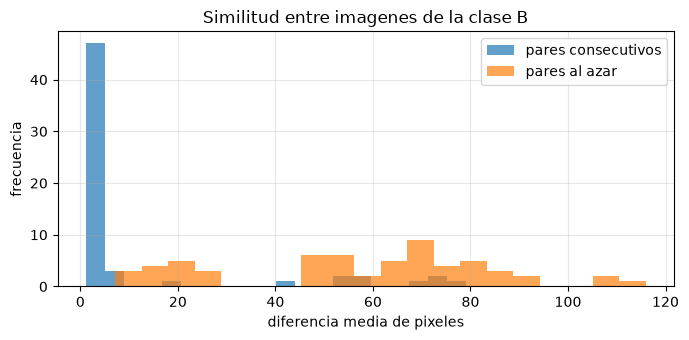

In [14]:
LETRA_TEST = "B"
archivos_ordenados = rutas[LETRA_TEST]

def cargar_gris(p):
    with Image.open(p) as img:
        return np.asarray(img.convert("L").resize((64, 64)), dtype="float32")

# Pares consecutivos (A1-A2, A2-A3, ...) en 60 posiciones aleatorias
posiciones = rng.choice(len(archivos_ordenados) - 1, 60, replace=False)
dif_consecutivas = [np.abs(cargar_gris(archivos_ordenados[i])
                           - cargar_gris(archivos_ordenados[i + 1])).mean()
                    for i in posiciones]

# Pares al azar dentro de la misma clase
a = rng.choice(len(archivos_ordenados), 60, replace=False)
b = rng.choice(len(archivos_ordenados), 60, replace=False)
dif_aleatorias = [np.abs(cargar_gris(archivos_ordenados[i])
                         - cargar_gris(archivos_ordenados[j])).mean()
                  for i, j in zip(a, b)]

print(f"Clase analizada: {LETRA_TEST}")
print(f"Diferencia media entre imagenes CONSECUTIVAS: {np.mean(dif_consecutivas):.2f}")
print(f"Diferencia media entre imagenes AL AZAR:      {np.mean(dif_aleatorias):.2f}")
print(f"Razon: {np.mean(dif_aleatorias) / np.mean(dif_consecutivas):.2f}x")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(dif_consecutivas, bins=20, alpha=0.7, label="pares consecutivos")
ax.hist(dif_aleatorias, bins=20, alpha=0.7, label="pares al azar")
ax.set_xlabel("diferencia media de pixeles"); ax.set_ylabel("frecuencia")
ax.set_title(f"Similitud entre imagenes de la clase {LETRA_TEST}")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

El resultado es contundente. Dos imágenes con números consecutivos difieren en promedio **11.89** unidades de píxel, mientras que dos imágenes al azar de la misma clase difieren **57.12**. Los pares consecutivos son **4.81 veces más parecidos** entre sí.

El histograma lo muestra sin ambigüedad, casi todos los pares consecutivos se apilan cerca de cero (prácticamente el mismo fotograma), mientras que los pares al azar se reparten entre 40 y 120. Las dos distribuciones casi no se traslapan.

**¿Por qué importa?** Las fotos se capturaron en video continuo, así que `B1.jpg` y `B2.jpg` son casi la misma imagen. Si una cae en entrenamiento y la otra en prueba, el modelo acertará en la de prueba porque **ya la vio**, no porque haya aprendido la seña. La exactitud reportada saldría inflada. Este hallazgo condiciona directamente cómo se arma la partición.

### 4.9 El conjunto de prueba oficial de Kaggle

El dataset trae un conjunto de prueba propio. Se revisa qué tan grande es antes de decidir si
sirve para evaluar el modelo.

Imagenes en el conjunto de prueba oficial: 28
Nombres: ['A_test', 'B_test', 'C_test', 'D_test', 'E_test', 'F_test', 'G_test', 'H_test', 'I_test', 'J_test', 'K_test', 'L_test', 'M_test', 'N_test', 'O_test', 'P_test', 'Q_test', 'R_test', 'S_test', 'T_test', 'U_test', 'V_test', 'W_test', 'X_test', 'Y_test', 'Z_test', 'nothing_test', 'space_test']


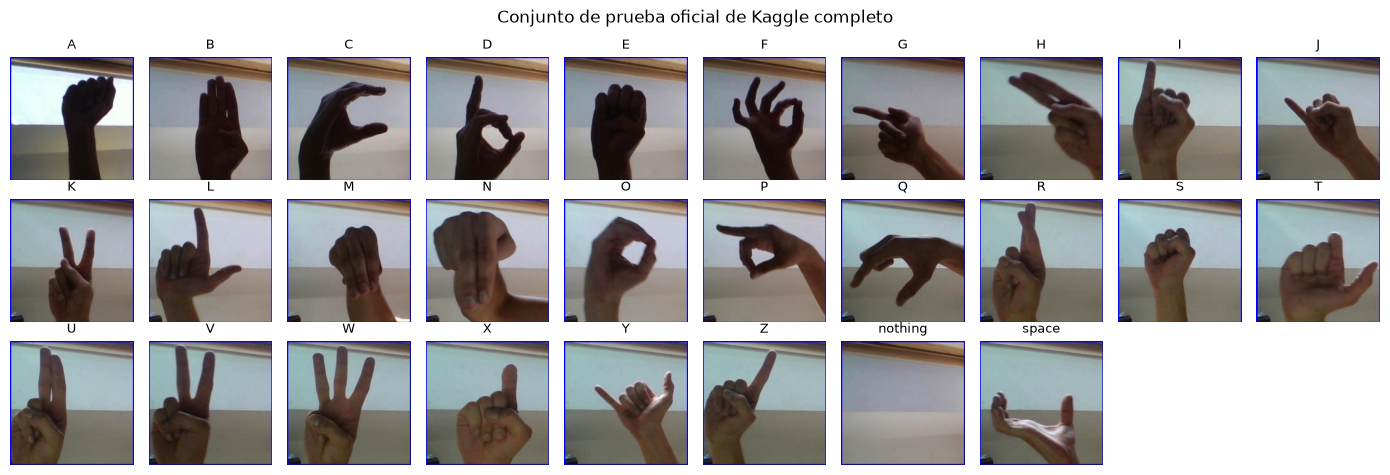

In [15]:
test_oficial = sorted(Path("..", "data", "raw_test_oficial").glob("*.jpg"))
print(f"Imagenes en el conjunto de prueba oficial: {len(test_oficial)}")
print("Nombres:", [p.stem for p in test_oficial])

fig, axes = plt.subplots(3, 10, figsize=(14, 4.8))
for k, ax in enumerate(axes.flat):
    if k < len(test_oficial):
        ax.imshow(Image.open(test_oficial[k]))
        ax.set_title(test_oficial[k].stem.replace("_test", ""), fontsize=9)
    ax.axis("off")
fig.suptitle("Conjunto de prueba oficial de Kaggle completo")
plt.tight_layout()
plt.show()

El conjunto de prueba oficial tiene **28 imágenes: una sola por clase** (no están las 29, falta `del`). Con una imagen por clase, la exactitud solo puede tomar 29 valores distintos y un acierto o error individual mueve el resultado en 3.6 puntos porcentuales. **No sirve para medir nada de forma confiable**.

Vale la pena notar otra cosa en las imágenes: están encuadradas más de cerca y en general mejor iluminadas que las de entrenamiento. Son útiles como una prueba cualitativa extra (una pequeña muestra de datos "distintos") pero no como métrica.

### 4.10 Definición del propio conjunto de entrenamiento / validación / prueba

Con lo observado se define la estrategia de partición. Las decisiones y su justificación:

| Decisión | Valor | Por qué |
|---|---|---|
| Fuente | Solo el conjunto de entrenamiento oficial | El test oficial es demasiado pequeño para medir nada |
| Submuestra | 500 imágenes por clase (14,500 en total) | El dataset completo no cabe en la memoria disponible; 500 por clase mantiene el balance perfecto |
| Selección | Aleatoria dentro de cada clase, con semilla fija | Tomar los primeros 500 archivos daría un bloque de fotogramas casi idénticos |
| Partición | 70 % entrenamiento / 15 % validación / 15 % prueba | Estándar; deja suficientes datos para entrenar y dos conjuntos independientes para ajustar y evaluar |
| Estratificación | `stratify=y` en ambos cortes | Conserva las 29 clases balanceadas en las tres particiones |
| Semilla | 42 | Reproducibilidad |

El cálculo de cuántas imágenes queda en cada partición:

In [16]:
PER_CLASS = 500
n_total = PER_CLASS * len(dl.CLASES)

reparto = pd.DataFrame({
    "particion": ["entrenamiento", "validacion", "prueba"],
    "proporcion": [0.70, 0.15, 0.15],
})
reparto["imagenes"] = (reparto["proporcion"] * n_total).astype(int)
reparto["por clase"] = reparto["imagenes"] // len(dl.CLASES)

print(f"Submuestra total: {n_total:,} imagenes ({PER_CLASS} por clase)\n")
print(reparto.to_string(index=False))
print(f"\nMemoria estimada a 64x64 en uint8: {n_total * 64 * 64 * 3 / 1e6:.0f} MB")
print(f"Memoria si se usara la resolucion original 200x200: "
      f"{n_total * 200 * 200 * 3 / 1e6:.0f} MB")

Submuestra total: 14,500 imagenes (500 por clase)

    particion  proporcion  imagenes  por clase
entrenamiento        0.70     10150        350
   validacion        0.15      2175         75
       prueba        0.15      2175         75

Memoria estimada a 64x64 en uint8: 178 MB
Memoria si se usara la resolucion original 200x200: 1740 MB


### 4.11 ¿Cuánta fuga de fotogramas queda tras submuestrear?

La sección 4.8 mostró que los fotogramas consecutivos son casi idénticos. Como la submuestra toma solo 500 de las 3,000 imágenes de cada clase, muchos de esos pares vecinos se rompen: si se elige `B1500.jpg`, lo más probable es que `B1501.jpg` no entre en la submuestra. Se mide qué tanto ayuda esto.

In [17]:
# Con la submuestra ya definida, se mide cuantas imagenes elegidas tienen un
# fotograma vecino (numero consecutivo) tambien dentro de la submuestra.
import re
import preprocess as pp

rutas_sub, _ = pp.submuestrear(per_class=PER_CLASS, seed=SEED)

elegidos = {}
for p in rutas_sub:
    numero = int(re.findall(r"(\d+)", p.stem)[-1])
    elegidos.setdefault(p.parent.name, set()).add(numero)

con_vecino = sum(1 for nums in elegidos.values() for n in nums
                 if (n - 1) in nums or (n + 1) in nums)

print(f"Imagenes en la submuestra: {len(rutas_sub):,}")
print(f"De ellas, con un fotograma vecino tambien en la submuestra: "
      f"{con_vecino:,} ({con_vecino / len(rutas_sub):.1%})")

Imagenes en la submuestra: 14,500
De ellas, con un fotograma vecino tambien en la submuestra: 4,383 (30.2%)


**Interpretación**

Tomar 500 de las 3,000 imágenes de cada clase reduce el problema pero no lo elimina: alrededor de un tercio de la submuestra conserva un fotograma vecino. Una parte de esos pares terminará repartida entre entrenamiento y prueba.

**¿Qué se hace al respecto?** Se acepta la partición aleatoria estratificada, que es el procedimiento estándar y el que se pide, pero se deja documentada la consecuencia: **la exactitud que reporten los modelos sobre este conjunto de prueba estará algo optimista** respecto a lo que lograrían con fotos genuinamente nuevas.

Una alternativa más estricta sería partir por **bloques contiguos de fotogramas** (por ejemplo, las imágenes 1–2100 de cada clase a entrenamiento y las 2101–3000 a prueba) en vez de al azar. Eso eliminaría la fuga, pero como las condiciones de luz cambian a lo largo de la sesión de grabación, introduciría un desfase sistemático entre los conjuntos que complicaría la comparación entre modelos.

## 5. Resumen de hallazgos

### Sobre el formato de los datos

1. El dataset tiene **87,000 imágenes** repartidas en **29 clases**, todas de **200×200
   píxeles**, formato **JPEG** y modo **RGB**, sin una sola excepción. La única característica que hace falta homogeneizar es el marco azul saturado de las fotos. El cuaderno `02_preprocesamiento.ipynb` lo mide y lo recorta.)
2. Está **perfectamente balanceado**: exactamente 3,000 imágenes por clase. La exactitud es
   una métrica válida y la línea base de azar es 3.4 %.

### Sobre la variabilidad

3. La variación dominante dentro de una clase es la **iluminación**. En la letra A el brillo
   medio va de 80 a 160 entre distintas tomas de la misma seña.
4. Esa variación *dentro* de cada clase (~100 puntos de brillo) es unas **tres veces mayor**
   que la variación *entre* clases (~34 puntos), así que la iluminación no funciona como
   "atajo" para clasificar.
5. El **color no distingue las letras**: los promedios RGB por clase varían apenas un 5 %
   entre sí. Todas las fotos son de la misma persona, el mismo cuarto y la misma luz.
6. Las imágenes promedio muestran que **el fondo es más estable que la mano**: la esquina de
   la pared sobrevive nítida al promedio mientras que la mano se difumina. Y los mapas de
   desviación estándar muestran que la mayor variación de píxeles la produce la luz sobre
   toda la escena, no la mano.

### Sobre las letras que se confunden

7. Los seis pares que anticipa el laboratorio (**M/N/S** y **U/V/R**) caen todos en el cuartil
   de pares más parecidos entre los 406 posibles, lo cual valida la sospecha.
8. Los datos añaden que el grupo **U/V/R** (puestos 6, 13 y 21) se parece más entre sí que el
   grupo **M/N/S** (puestos 20, 52 y 109), y señalan pares que las instrucciones no mencionan:
   **T–U, T–W, U–W, S–Y y W–Y**. Todos pertenecen al mismo bloque de letras con la mano
   compacta.
9. `nothing` es la clase más distinta de todas: es la única sin mano en el cuadro.

### Sobre cómo repartir los datos

10. Las fotos provienen de **secuencias de video**: dos imágenes con números consecutivos son
    4.81 veces más parecidas entre sí que dos al azar de la misma clase.
11. El **conjunto de prueba oficial de Kaggle tiene 28 imágenes** (una por clase, y le falta
    `del`), así que no permite medir nada de forma confiable. Se construye un conjunto propio.
12. La partición elegida es **70/15/15 estratificada** sobre una submuestra de **500 imágenes
    aleatorias por clase**, con semilla 42. Un tercio de la submuestra conserva algún
    fotograma vecino, así que la exactitud sobre el conjunto de prueba quedará algo optimista;
    la prueba real será el ejercicio 8 con fotos propias.

### Lo que esto implica para el modelado

- Un buen resultado aquí no garantiza un buen resultado con usuarios reales.
- El modelo debe ser **robusto a la iluminación**, que es la mayor fuente de variación.
- El aumento de datos con **brillo, contraste, zoom y traslación** reproduce variaciones que
  ya existen en los datos; el **volteo horizontal no**, porque todo el dataset es de la mano
  derecha.
- Se debe vigilar de cerca la **matriz de confusión** en los bloques M/N/S, U/V/R y
  T/U/W/S/Y.